# TimelyGPT + PTB-XL — setup

Get the `TimelyGPT_CTS` code and enough PTB-XL ECG data into a Colab session,
confirm both load, and produce the tensor the encoder expects.

**Plumbing only — no modelling.** Run the cells in order.

Deliverable for Prof. Li is a *working pipeline*, not a trained model, so this
notebook deliberately downloads a **subset** of PTB-XL (~1000 records, ~1 min)
rather than all 21,799. Section 5 has the full-dataset option when you need it.

## 1. Session check

In [1]:
import torch, sys
print("python :", sys.version.split()[0])
print("torch  :", torch.__version__)
print("cuda   :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("device :", torch.cuda.get_device_name(0))
else:
    print("No GPU — fine for this notebook. Runtime > Change runtime type > T4 when you need one.")
!df -h /content | tail -1

python : 3.13.15
torch  : 2.11.0+cu128
cuda   : True
device : Tesla T4
overlay         113G   48G   66G  42% /


## 2. Mount Drive (do this first)

Colab wipes `/content` on disconnect. Mounting now means you download PTB-XL
once instead of every session.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os
WORK = "/content/drive/MyDrive/timelygpt"
os.makedirs(WORK, exist_ok=True)
print("persistent workspace:", WORK)
print("contents:", os.listdir(WORK) or "(empty)")

Mounted at /content/drive
persistent workspace: /content/drive/MyDrive/timelygpt
contents: ['ptbxl', 'TimelyGPT_snapshot', 'ecgfm', 'ckpts', 'ecgfm_first_run.pt', 'demo_outputs.json']


## 3. Clone the repository

In [3]:
%cd /content
!rm -rf TimelyGPT
!git clone --depth 1 https://github.com/li-lab-mcgill/TimelyGPT.git
%cd /content/TimelyGPT
!git log -1 --format="last commit: %h  %ad  %s" --date=short

/content
Cloning into 'TimelyGPT'...
remote: Enumerating objects: 44, done.
remote: Counting objects: 100% (44/44), done.
remote: Compressing objects: 100% (37/37), done.
remote: Total 44 (delta 5), reused 39 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (44/44), 207.74 KiB | 1022.00 KiB/s, done.
Resolving deltas: 100% (5/5), done.
/content/TimelyGPT
last commit: 3268f15  2025-10-12  Update README.md


## 4. Discover the structure

Do not assume filenames. Print what is actually there, then adapt the imports
in section 8 to match.

In [4]:
import os

for root, dirs, files in os.walk("/content/TimelyGPT"):
    dirs[:] = [d for d in dirs if d not in {".git", "__pycache__", ".ipynb_checkpoints"}]
    depth = root.replace("/content/TimelyGPT", "").count(os.sep)
    if depth > 2:
        continue
    print(f"{'  ' * depth}{os.path.basename(root) or 'TimelyGPT'}/")
    for f in sorted(files):
        if f.endswith((".py", ".md", ".txt", ".yaml", ".yml", ".json")):
            kb = os.path.getsize(os.path.join(root, f)) // 1024
            print(f"{'  ' * (depth + 1)}{f}  ({kb} KB)")

TimelyGPT/
  README.md  (2 KB)
  TimelyGPT_ISTS/
    run_pretrain_ists.py  (7 KB)
    data/
      data_pipeline.py  (4 KB)
    layers/
      Conv_layers.py  (9 KB)
      Embed.py  (2 KB)
      Retention_ISTS_layers.py  (9 KB)
      Xpos.py  (3 KB)
      configs.py  (1 KB)
      conv1d_test.py  (5 KB)
      heads.py  (0 KB)
      med_tokenizer.py  (3 KB)
      optimization.py  (9 KB)
      snippets.py  (4 KB)
    models/
      TimelyGPT.py  (9 KB)
  TimelyGPT_CTS/
    run_pretrain.py  (8 KB)
    data/
      data_pipeline.py  (2 KB)
    layers/
      Conv_layers.py  (8 KB)
      Retention_layers.py  (12 KB)
      RevIN.py  (2 KB)
      Xpos.py  (3 KB)
      configs.py  (1 KB)
      heads.py  (2 KB)
      optimization.py  (9 KB)
      snippets.py  (4 KB)
    models/
      TimelyGPT.py  (8 KB)
  figures/


In [5]:
# The continuous-time-series path is the one that matters for ECG.
CTS = "/content/TimelyGPT/TimelyGPT_CTS"   # adjust from the tree above if needed

if os.path.isdir(CTS):
    for root, dirs, files in os.walk(CTS):
        dirs[:] = [d for d in dirs if d not in {"__pycache__", ".ipynb_checkpoints"}]
        rel = os.path.relpath(root, CTS)
        print(f"\n[{'CTS root' if rel == '.' else rel}]")
        for f in sorted(files):
            print("   ", f)
else:
    print("Not found. Set CTS from the tree above.")


[CTS root]
    run_pretrain.py

[data]
    data_pipeline.py

[layers]
    Conv_layers.py
    Retention_layers.py
    RevIN.py
    Xpos.py
    configs.py
    heads.py
    optimization.py
    snippets.py

[models]
    TimelyGPT.py


In [6]:
# Is the conv subsampler live here? (In the ISTS/PheCode path it was commented out.
# Expect it to be ACTIVE for ECG — dense waveform genuinely needs compression.)
!grep -rn "Conv1dSubampling" /content/TimelyGPT --include=*.py | head -30

/content/TimelyGPT/TimelyGPT_ISTS/layers/Conv_layers.py:166:class Conv1dSubampling_new(nn.Module):
/content/TimelyGPT/TimelyGPT_ISTS/layers/Conv_layers.py:168:        super(Conv1dSubampling_new, self).__init__()
/content/TimelyGPT/TimelyGPT_ISTS/layers/Conv_layers.py:195:class Conv1dSubampling(nn.Module):
/content/TimelyGPT/TimelyGPT_ISTS/layers/Conv_layers.py:211:        super(Conv1dSubampling, self).__init__()
/content/TimelyGPT/TimelyGPT_ISTS/layers/Conv_layers.py:265:subsampling_layer = Conv1dSubampling_new(in_channels=in_channels, out_channels=out_channels)
/content/TimelyGPT/TimelyGPT_ISTS/layers/conv1d_test.py:21:class Conv1dSubampling_new(nn.Module):
/content/TimelyGPT/TimelyGPT_ISTS/layers/conv1d_test.py:23:        super(Conv1dSubampling_new, self).__init__()
/content/TimelyGPT/TimelyGPT_ISTS/layers/conv1d_test.py:48:class Conv1dSubampling(nn.Module):
/content/TimelyGPT/TimelyGPT_ISTS/layers/conv1d_test.py:64:        super(Conv1dSubampling, self).__init__()
/content/TimelyGPT/

In [7]:
# Model class and the subsampling factor
!grep -rn "class TimelyGPT" /content/TimelyGPT --include=*.py
print("-" * 70)
!grep -rn "reduce_time_layers" /content/TimelyGPT --include=*.py | head -20

/content/TimelyGPT/TimelyGPT_ISTS/models/TimelyGPT.py:16:class TimelyGPT(nn.Module):
/content/TimelyGPT/TimelyGPT_CTS/models/TimelyGPT.py:17:class TimelyGPT(nn.Module):
----------------------------------------------------------------------
/content/TimelyGPT/TimelyGPT_ISTS/layers/Conv_layers.py:167:    def __init__(self, in_channels: int, out_channels: int, reduce_time_layers: int = 2) -> None:
/content/TimelyGPT/TimelyGPT_ISTS/layers/Conv_layers.py:172:        for _ in range(reduce_time_layers):
/content/TimelyGPT/TimelyGPT_ISTS/layers/Conv_layers.py:201:        reduce_time_layers (int): Number of halving conv layers to apply (default is 2 for 1/4 reduction)
/content/TimelyGPT/TimelyGPT_ISTS/layers/Conv_layers.py:210:    def __init__(self, in_channels: int, out_channels: int, reduce_time_layers: int = 2) -> None:
/content/TimelyGPT/TimelyGPT_ISTS/layers/Conv_layers.py:215:        for _ in range(reduce_time_layers):
/content/TimelyGPT/TimelyGPT_ISTS/layers/Conv_layers.py:231:    def __

## 5. Dependencies

In [8]:
!pip install -q wfdb
import os
req = "/content/TimelyGPT/requirements.txt"
print(open(req).read() if os.path.exists(req) else "No requirements.txt at repo root.")
# !pip install -q -r {req}   # only if needed; may downgrade Colab packages

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 6.4 MB/s eta 0:00:00
No requirements.txt at repo root.


## 6. Get PTB-XL

PTB-XL v1.0.3 is open access — no credentialing.

**Default: subset.** One subfolder of `records100/` is ~1000 records and takes
about a minute. That is plenty to prove the pipeline runs.

Two flags matter: `-A "*.dat,*.hea"` and `-R "index.html*"` stop wget from
downloading a directory-listing HTML page for every folder it walks.

In [9]:
import os
PTB = os.path.join(WORK, "ptbxl")     # lives on Drive, survives disconnects
os.makedirs(PTB, exist_ok=True)

already = os.path.exists(os.path.join(PTB, "ptbxl_database.csv"))
print("already downloaded" if already else "will download")

already downloaded


In [10]:
# Metadata (small — always needed in full)
if not already:
    !cd "{PTB}" && wget -q --show-progress -nH --cut-dirs=4 \
        https://physionet.org/files/ptb-xl/1.0.3/ptbxl_database.csv \
        https://physionet.org/files/ptb-xl/1.0.3/scp_statements.csv
!ls -la "{PTB}"/*.csv

-rw------- 1 root root 6594879 Nov  3  2022 /content/drive/MyDrive/timelygpt/ptbxl/ptbxl_database.csv
-rw------- 1 root root    9720 Apr 23  2020 /content/drive/MyDrive/timelygpt/ptbxl/scp_statements.csv


In [11]:
# Waveform subset: folder 00000/ at 100 Hz  (~1000 records, ~1 min)
if not already:
    !cd "{PTB}" && wget -q --show-progress -r -N -np -nH --cut-dirs=4 \
        -A "*.dat,*.hea" -R "index.html*" \
        https://physionet.org/files/ptb-xl/1.0.3/records100/10000/

!du -sh "{PTB}"
!ls "{PTB}"

168M	/content/drive/MyDrive/timelygpt/ptbxl
00000  10000  ptbxl_database.csv  records500  scp_statements.csv


### Full dataset (only when you start training)

The zip is one connection at PhysioNet→Google speed, so it is **much** faster
than recursive wget over ~43,000 files. Uncomment when you need it.

In [12]:
# %cd /content
# !wget -q --show-progress -O ptbxl.zip \
#   https://physionet.org/static/published-projects/ptb-xl/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3.zip
# !unzip -q -o ptbxl.zip -d /content/ptbxl_full
# !ls /content/ptbxl_full
print("Skipped — using the subset above.")

Skipped — using the subset above.


## 7. Metadata, and what you actually have on disk

`scp_codes` maps through `scp_statements.csv` to the 5 diagnostic superclasses
(NORM, MI, STTC, CD, HYP). `strat_fold` is the official 10-fold split — use
fold 10 as test so your numbers are comparable to published work.

In [13]:
import pandas as pd, ast, os

df = pd.read_csv(os.path.join(PTB, "ptbxl_database.csv"), index_col="ecg_id")
df.scp_codes = df.scp_codes.apply(ast.literal_eval)

agg = pd.read_csv(os.path.join(PTB, "scp_statements.csv"), index_col=0)
agg = agg[agg.diagnostic == 1]

def to_superclass(codes):
    out = set()
    for k in codes:
        if k in agg.index and pd.notna(agg.loc[k].diagnostic_class):
            out.add(agg.loc[k].diagnostic_class)
    return sorted(out)

df["superclass"] = df.scp_codes.apply(to_superclass)

print("records in metadata :", len(df))
print("patients            :", df.patient_id.nunique())

records in metadata : 21799
patients            : 18869


In [14]:
!find "{PTB}" -name "*.dat" | head -3
!ls "{PTB}"

/content/drive/MyDrive/timelygpt/ptbxl/00000/00494_lr.dat
/content/drive/MyDrive/timelygpt/ptbxl/00000/00492_lr.dat
/content/drive/MyDrive/timelygpt/ptbxl/00000/00508_lr.dat
00000  10000  ptbxl_database.csv  records500  scp_statements.csv


In [15]:
import os, glob

# Files sit at ptbxl/<subfolder>/, metadata says records100/<subfolder>/
def resolve(fn):
    stem = os.path.splitext(fn)[0]                    # records100/00000/00001_lr
    flat = stem.replace("records100/", "")            # 00000/00001_lr
    for cand in (os.path.join(PTB, stem), os.path.join(PTB, flat)):
        if os.path.exists(cand + ".dat"):
            return cand
    return None

df["path"] = df.filename_lr.apply(resolve)
sub = df[df.path.notna()].copy()

print("available locally:", len(sub))
print(sub.superclass.explode().value_counts(dropna=False))

missing = {"NORM", "MI", "STTC", "CD", "HYP"} - set(sub.superclass.explode().dropna())
print("missing classes:", missing or "none")

available locally: 1987
superclass
NORM    966
STTC    485
CD      423
MI      416
HYP     241
NaN      26
Name: count, dtype: int64
missing classes: none


In [16]:
import numpy as np
import wfdb

def load_batch(frame, n=8):
    return np.stack([wfdb.rdsamp(p)[0] for p in frame.path.head(n)]).astype(np.float32)

batch = load_batch(sub, n=8)
x = torch.from_numpy(batch)
print(x.shape)   # expect (8, 1000, 12)

torch.Size([8, 1000, 12])


## 8. Read one waveform

10 s at 100 Hz = 1000 timesteps, 12 leads.

In [17]:
row = sub.iloc[0]
signal, meta = wfdb.rdsamp(row.path)

print("shape      :", signal.shape, "-> (timesteps, leads)")
print("fs         :", meta["fs"], "Hz")
print("leads      :", meta["sig_name"])
print("duration   :", signal.shape[0] / meta["fs"], "s")
print("superclass :", row.superclass)
print("range      : %.3f to %.3f mV" % (signal.min(), signal.max()))

shape      : (1000, 12) -> (timesteps, leads)
fs         : 100 Hz
leads      : ['I', 'II', 'III', 'AVR', 'AVL', 'AVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
duration   : 10.0 s
superclass : ['NORM']
range      : -1.377 to 0.706 mV


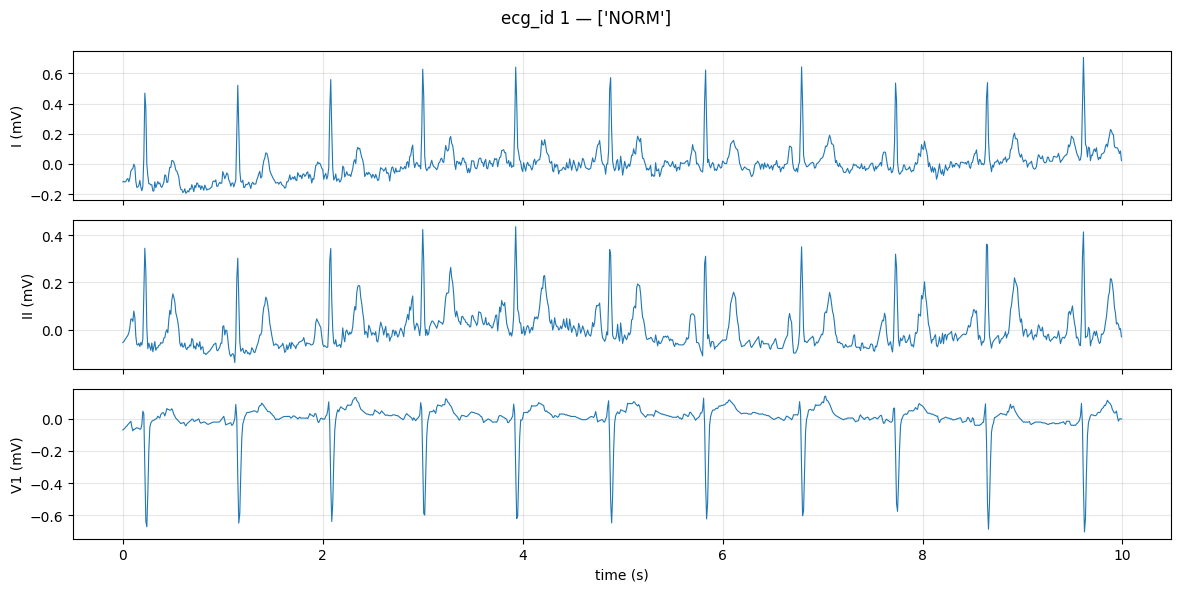

In [18]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(12, 6), sharex=True)
t = np.arange(signal.shape[0]) / meta["fs"]
for ax, lead in zip(axes, ["I", "II", "V1"]):
    ax.plot(t, signal[:, meta["sig_name"].index(lead)], lw=0.8)
    ax.set_ylabel(f"{lead} (mV)")
    ax.grid(alpha=0.3)
axes[-1].set_xlabel("time (s)")
fig.suptitle(f"ecg_id {sub.index[0]} — {row.superclass}")
plt.tight_layout(); plt.show()

## 9. Batch, and the shape TimelyGPT expects

The subsampler takes `(batch, time, channels)` and permutes internally. Its own
test harness used `in_channels=12, seq_length=4096` — so 12-lead ECG is exactly
what this code path was written for.

Note the length difference: PTB-XL at 100 Hz is 1000 steps, not 4096. Conv
layers are length-agnostic, but check whether the model config assumes a fixed
sequence length. If it does, either use `records500` (5000 steps) or adjust it.

In [19]:
def load_batch(frame, n=8):
    """Return (n, time, 12) float32."""
    sigs = [wfdb.rdsamp(p)[0] for p in frame.path.head(n)]
    return np.stack(sigs).astype(np.float32)

batch = load_batch(sub, n=8)
x = torch.from_numpy(batch)
print("numpy :", batch.shape)
print("tensor:", x.shape, "-> (batch, time, leads)")
print("dtype :", x.dtype)
print("NaNs  :", torch.isnan(x).any().item())

numpy : (8, 1000, 12)
tensor: torch.Size([8, 1000, 12]) -> (batch, time, leads)
dtype : torch.float32
NaNs  : False


In [20]:
import sys, importlib, pkgutil, os

sys.path.insert(0, CTS)

# Locate the module that actually defines Conv1dSubampling
target = None
for root, _, files in os.walk(CTS):
    for f in files:
        if f.endswith(".py"):
            p = os.path.join(root, f)
            if "class Conv1dSubampling" in open(p, errors="ignore").read():
                rel = os.path.relpath(p, CTS)[:-3].replace(os.sep, ".")
                target = rel
                print("found in:", rel)
if target is None:
    raise ImportError("Conv1dSubampling not found under CTS")

mod = importlib.import_module(target)
Conv1dSubampling = mod.Conv1dSubampling

found in: layers.Conv_layers


In [21]:
sub_layer = Conv1dSubampling(in_channels=12, out_channels=320, reduce_time_layers=2)
sub_layer.eval()

with torch.no_grad():
    y = sub_layer(x)

print("type:", type(y), "len:", len(y))
for i, t in enumerate(y):
    print(f"  [{i}]", tuple(t.shape))

type: <class 'tuple'> len: 2
  [0] (8, 250, 320)
  [1] (8, 250, 12)


In [22]:
outputs, tokens = y

print("in      :", tuple(x.shape))
print("outputs :", tuple(outputs.shape))
print("tokens  :", tuple(tokens.shape))
print("reduction factor:", x.shape[1] / outputs.shape[1])

in      : (8, 1000, 12)
outputs : (8, 250, 320)
tokens  : (8, 250, 12)
reduction factor: 4.0


## 10. Save state

In [23]:
# Keep a copy of the repo on Drive too (so a specific commit is reproducible)
!cp -r /content/TimelyGPT "{WORK}/TimelyGPT_snapshot" 2>/dev/null || echo "snapshot exists"
!du -sh "{WORK}"/*

1.1G	/content/drive/MyDrive/timelygpt/ckpts
1.0K	/content/drive/MyDrive/timelygpt/demo_outputs.json
1.1G	/content/drive/MyDrive/timelygpt/ecgfm
4.5M	/content/drive/MyDrive/timelygpt/ecgfm_first_run.pt
168M	/content/drive/MyDrive/timelygpt/ptbxl
1.6M	/content/drive/MyDrive/timelygpt/TimelyGPT_snapshot


## Next

1. Adapt the import in section 9; confirm the realised reduction factor on ECG
   (expect **4x** — unlike the 1x you measured on the PheCode path).
2. Instantiate the TimelyGPT model, run `x` through it, record the hidden-state
   shape and `d_model`.
3. Add `nn.Linear(d_model → d_llm)` and the resampler; confirm
   `(batch, N, d_llm)` — same as the PheCode experiment.
4. One qualitative end-to-end example: an ECG in, a sentence out.

**Do not train anything yet.** A screenshot of the model saying something about
a real ECG — even something wrong — is worth more to Prof. Li than a page of
shape assertions. Wrong-but-running is a result; not-yet-running is not.

**Open design question worth thinking about before the meeting:** on EHRSHOT the
text stream comes from clinical codes. An ECG has none. So what does the LLM
receive alongside the representation — the SCP diagnostic labels? a generated
description? nothing at all? Look at **ECG-QA** (built on PTB-XL) for one
existing answer.

In [24]:
import os, importlib

hits = []
for root, _, files in os.walk(CTS):
    for f in files:
        if f.endswith(".py"):
            p = os.path.join(root, f)
            src = open(p, errors="ignore").read()
            for line in src.splitlines():
                if line.strip().startswith("class ") and "TimelyGPT" in line:
                    rel = os.path.relpath(p, CTS)[:-3].replace(os.sep, ".")
                    hits.append((rel, line.strip()))

for rel, line in hits:
    print(f"{rel:40s} {line}")

models.TimelyGPT                         class TimelyGPT(nn.Module):


In [25]:
import os

for folder in sorted(os.listdir("/content/TimelyGPT")):
    lp = os.path.join("/content/TimelyGPT", folder, "layers")
    if os.path.isdir(lp):
        print(f"\n[{folder}/layers]")
        for f in sorted(os.listdir(lp)):
            if f.endswith(".py"):
                print("   ", f)


[TimelyGPT_CTS/layers]
    Conv_layers.py
    Retention_layers.py
    RevIN.py
    Xpos.py
    configs.py
    heads.py
    optimization.py
    snippets.py

[TimelyGPT_ISTS/layers]
    Conv_layers.py
    Embed.py
    Retention_ISTS_layers.py
    Xpos.py
    configs.py
    conv1d_test.py
    heads.py
    med_tokenizer.py
    optimization.py
    snippets.py


In [26]:
!grep -rn "class TokenEmbeddingFixed" /content/TimelyGPT --include=*.py

/content/TimelyGPT/TimelyGPT_ISTS/layers/Embed.py:44:class TokenEmbeddingFixed(nn.Module):


In [27]:
import os
ists = set(f for f in os.listdir("/content/TimelyGPT/TimelyGPT_ISTS/layers") if f.endswith(".py"))
cts  = set(f for f in os.listdir(f"{CTS}/layers") if f.endswith(".py"))

print("CTS has   :", sorted(cts))
print("ISTS only :", sorted(ists - cts))
print("CTS only  :", sorted(cts - ists))

CTS has   : ['Conv_layers.py', 'Retention_layers.py', 'RevIN.py', 'Xpos.py', 'configs.py', 'heads.py', 'optimization.py', 'snippets.py']
ISTS only : ['Embed.py', 'Retention_ISTS_layers.py', 'conv1d_test.py', 'med_tokenizer.py']
CTS only  : ['Retention_layers.py', 'RevIN.py']


In [28]:
!cp /content/TimelyGPT/TimelyGPT_ISTS/layers/Embed.py "{CTS}/layers/"
!head -20 "{CTS}/layers/Embed.py"

import time
import pandas as pd
import math
import torch
import torch.nn as nn


class PositionalEmbedding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super(PositionalEmbedding, self).__init__()
        # Compute the positional encodings once in log space.
        pe = torch.zeros(max_len, d_model).float()
        pe.require_grad = False

        position = torch.arange(0, max_len).float().unsqueeze(1)
        div_term = (torch.arange(0, d_model, 2).float() * -(math.log(10000.0) / d_model)).exp()

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)



In [29]:
!sed -n '44,90p' "{CTS}/layers/Embed.py"

class TokenEmbeddingFixed(nn.Module):
    def __init__(self, embedding_path):
        super(TokenEmbeddingFixed, self).__init__()

        # Load pre-trained embeddings
        embedding_df = pd.read_csv(embedding_path, index_col=0)
        embeddings = torch.tensor(embedding_df.values, dtype=torch.float32)
        # Create PheCode to index mapping
        self.phecode_to_index = {int(phecode): idx for idx, phecode in enumerate(embedding_df.index)}
        # Add a padding index entry
        self.padding_idx = len(self.phecode_to_index)
        embeddings = torch.cat([embeddings, torch.zeros(1, embeddings.shape[1])], dim=0)  # Add a zero vector for padding
        # Create embedding layer with pre-trained weights
        self.emb = nn.Embedding.from_pretrained(embeddings, freeze=True, padding_idx=self.padding_idx)

    def get_num_tokens(self):
        return len(self.phecode_to_index)  # Exclude the padding index

    def map_phecodes_to_indices(self, phecodes):
        indices = [sel

In [30]:
import importlib, inspect
mod = importlib.import_module("models.TimelyGPT")
TimelyGPT = mod.TimelyGPT
print(inspect.signature(TimelyGPT.__init__))
print("-" * 70)
print(inspect.getsource(TimelyGPT.forward))

(self, configs, head_type='pretrain')
----------------------------------------------------------------------
    def forward(self,
                X, y,
                retention_mask: Optional[torch.Tensor] = None,
                past_key_values: Optional[List[torch.FloatTensor]] = None,
                forward_impl: Optional[str] = 'parallel',
                chunk_size: Optional[int] = None,
                sequence_offset: Optional[int] = 0,
                output_retentions: Optional[bool] = None,
                output_hidden_states: Optional[bool] = None,
                ):
        # Use ConvSubsampling as tokenizer, input_project as embedding layer
        X, X_tokens = self.conv_subsampling(X)
        hidden_states = self.input_projection(X)
        batch_size, seq_len, dim = X.shape

        # Add the SOS token to the input sequence
        sos_token = self.sos.unsqueeze(0).repeat(batch_size, 1, 1)  # Shape [batch_size, 1, d_model]
        # Add the SOS token for shifted rig

In [31]:
!find /content/TimelyGPT -name "*.pt" -o -name "*.pth" -o -name "*.ckpt" -o -name "*.bin"

In [32]:
!find /content/TimelyGPT -type f \( -name "*.pt" -o -name "*.pth" -o -name "*.ckpt" -o -name "*.bin" -o -name "*.safetensors" \) 2>/dev/null
!du -sh /content/TimelyGPT

984K	/content/TimelyGPT


In [33]:
!cat /content/TimelyGPT/README.md
!grep -rin "checkpoint\|pretrained\|weights\|download\|zenodo\|huggingface\|drive.google" \
    /content/TimelyGPT --include=*.md --include=*.py --include=*.txt | head -20

# TimelyGPT

TimelyGPT is a extrapolatable time-serie generative pre-training Transformer designed for representation learning and health forecasting. 
This model is designed to model both continuous time series (e.g., biosignals) and irregularly-sampled time series (e.g., longitudinal electronic health records).


# Overview

This figure indicates an overview of TimelyGPT architecture.

***Panel a***. TimelyGPT Architecture. It shows that an example of continuous time-series data is first tokenized by a two-layer 1D convolutional subsampler and then projected into a $d$-dimensional space. A stack of $L$ generative decoder layers then processes it, and an output projection finally produces the next-token predictions.

***Panel b***. Each decoder layer is coupled with xPos embedding that encodes trend and periodic patterns into time-series representations, facilitating forecasting with extrapolation ability.

***Panel c***. Chunk-wise Retention consists of parallel intra-chunk Retention

In [34]:
import inspect
from layers import configs as cfg_mod
print([n for n in dir(cfg_mod) if not n.startswith("_")])

['PretrainedConfig', 'RetNetConfig', 'load_config_from_yaml', 'yaml']


In [35]:
!ls /content/TimelyGPT/

figures  notebook.ipynb  README.md  TimelyGPT_CTS  TimelyGPT_ISTS


In [36]:
import json
nb = json.load(open("/content/TimelyGPT/notebook.ipynb"))
for i, c in enumerate(nb["cells"]):
    src = "".join(c["source"])
    if c["cell_type"] == "code" and src.strip():
        print(f"--- cell {i} ---")
        print(src)

--- cell 4 ---
import torch
from torch.utils.data import DataLoader
--- cell 5 ---
import pandas as pd

# 1) Load the processed_pophr_data file
df = pd.read_csv('data/processed_pophr_data.csv')

# 2) Show the top 10 rows
df.head(10)
--- cell 6 ---
## 1. Data Loading with `data_provider`

'''
The `data_provider` function (in `data/data_pipeline.py`) wraps our `EHRDataset`, which by default uses `max_length=256`. Any patient sequence longer than 256 visits will automatically be truncated by **removing the oldest (leftmost)** visits, keeping only the most recent 256 events.
'''

from data import data_pipeline
from data.data_pipeline import data_provider

# 2. Set parameters
batch_size = 32
max_length = 256

# 3. Load datasets and dataloaders
train_dataset, train_dataloader, \
valid_dataset, valid_dataloader, \
test_dataset, test_dataloader = data_provider(
    batch_size=batch_size,
    max_length=max_length
)

# 4. Inspect the Dataset object
print(f"Total training patients: {len(train_da

In [37]:
!find /content/TimelyGPT -name "*.yaml" -o -name "*.yml"

In [38]:
!ls "{CTS}"
!grep -rn "add_argument" "{CTS}"/*.py | head -40
!grep -rn "RetNetConfig(\|load_config_from_yaml\|TimelyGPT(" "{CTS}" --include=*.py | head

data  layers  models  run_pretrain.py
16:    parser.add_argument('--random_seed', type=int, default=2021, help='random seed')
19:    parser.add_argument('--is_training', type=int, default=1, help='status')
20:    parser.add_argument('--model', type=str, default='TimelyGPT', help='model name, options: [TimelyGPT]')
23:    parser.add_argument('--data', type=str, default='custom', help='continuous time series data')
24:    parser.add_argument('--root_path', type=str, default='./data/', help='root path of the data file')
25:    parser.add_argument('--data_path', type=str, default='data.csv', help='data file')
26:    parser.add_argument('--data_folder', type=str, default='sleepEDF', help='data file')
28:    parser.add_argument('--checkpoints', type=str, default='./checkpoints/', help='location of model checkpoints')
31:    parser.add_argument('--seq_len', type=int, default=256, help='input sequence length')
32:    parser.add_argument('--label_len', type=int, default=128, help='start token l

In [39]:
from argparse import Namespace

args = Namespace(
    # --- data ---
    c_in=12,          # 12 leads (default 1)
    seq_len=1000,     # PTB-XL @100Hz (default 256)
    label_len=128, pred_len=128, n_class=1, reg_dim=1,
    # --- model ---
    num_heads=4, num_layers=4,
    d_model=200, qk_dim=200, v_dim=200, ffn_proj_size=800,
    forward_impl='parallel',      # simpler than 'chunkwise' for one pass
    chunk_size=512,
    use_bias_in_msr=False, use_bias_in_mlp=True, use_bias_in_msr_out=False,
    use_default_gamma=False,
    forecasting_method='oneforward',
    moving_avg=25, factor=1, distil=True,
    dropout=0.1, activation='gelu', output_retentions=False,
    # --- misc (probably unused at construction, harmless) ---
    model='TimelyGPT', data='custom', batch_size=8, loss='mse',
)

args.use_grad_ckp = False
model = TimelyGPT(configs=args, head_type='pretrain')
model.eval()
print(sum(p.numel() for p in model.parameters()) / 1e6, "M params")

3.01134 M params


In [40]:
import inspect, re
src = inspect.getsource(TimelyGPT.__init__)
print(src)
print("\nconfig fields used:")
print(sorted(set(re.findall(r"configs\.(\w+)", src))))

    def __init__(self, configs, head_type='pretrain'):
        super(TimelyGPT, self).__init__()

        # load parameters
        self.num_layers = configs.num_layers
        self.num_heads = configs.num_heads
        self.d_model = configs.d_model
        self.qk_dim = configs.qk_dim
        self.v_dim = configs.v_dim if configs.v_dim else self.qk_dim
        self.dropout = configs.dropout

        # the start token for shifted right
        self.sos = torch.nn.Parameter(torch.zeros(self.d_model))
        nn.init.normal_(self.sos)

        # Initialize number of variates
        self.c_in = configs.c_in
        self.revin_layer = RevIN(self.c_in)

        # Integration of ConvSubampling for embedding
        self.conv_subsampling = Conv1dSubampling(in_channels=self.c_in, out_channels=self.d_model, reduce_time_layers=2)
        # Add ConvUpampling for upsampling, note that the argument intermediate_channels is not used
        self.conv_upsampling = Conv1dUpsampling(hidden_dim=self.d

In [41]:
used = set(re.findall(r"configs\.(\w+)", src))
print("missing:", sorted(used - set(vars(args))))

missing: []


In [42]:
!sed -n '90,110p' "{CTS}/run_pretrain.py"


    # random seed
    fix_seed = args.random_seed
    random.seed(fix_seed)
    torch.manual_seed(fix_seed)
    np.random.seed(fix_seed)

    args.use_gpu = True if torch.cuda.is_available() and args.use_gpu else False
    if args.use_gpu and args.use_multi_gpu:
        args.dvices = args.devices.replace(' ', '')
        device_ids = args.devices.split(',')
        args.device_ids = [int(id_) for id_ in device_ids]
        args.gpu = args.device_ids[0]
    device = torch.device('cuda:{}'.format(args.gpu))

    model = TimelyGPT(configs=args).to(device=device)
    pytorch_total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print('Total params: {}'.format(pytorch_total_params))

    criterion = nn.CrossEntropyLoss()
    model_optim = optim.Adam(model.parameters(), lr=0.000001)


In [43]:
args.use_grad_ckp = False

model = TimelyGPT(configs=args, head_type='pretrain')
model.eval()
print(f"{sum(p.numel() for p in model.parameters())/1e6:.1f}M params")

3.0M params


In [44]:
feats = {}
model.ln_f.register_forward_hook(lambda m, i, o: feats.__setitem__("h", o))

try:
    with torch.no_grad():
        _ = model(x, y=None)
except Exception as e:
    print("forward raised after hook fired:", type(e).__name__, e)

h = feats["h"]
print("hidden states:", tuple(h.shape))

hidden states: (8, 251, 200)


In [45]:
print([n for n, _ in model.named_children()])

['revin_layer', 'conv_subsampling', 'conv_upsampling', 'input_projection', 'blocks', 'ln_f', 'head', 'mse_loss']


In [46]:
import torch.nn as nn

class Resampler(nn.Module):
    def __init__(self, dim, n_queries=32, n_heads=8):
        super().__init__()
        self.queries = nn.Parameter(torch.randn(n_queries, dim) * 0.02)
        self.attn = nn.MultiheadAttention(dim, n_heads, batch_first=True)
        self.ln = nn.LayerNorm(dim)
    def forward(self, kv):
        q = self.queries.unsqueeze(0).expand(kv.size(0), -1, -1)
        out, _ = self.attn(q, kv, kv)
        return self.ln(out)

d_model = h.shape[-1]      # 200
d_llm   = 768
N       = 32

resampler = Resampler(d_llm, N).eval()

In [47]:
proj = nn.Linear(d_model, d_llm)

with torch.no_grad():
    z = proj(h)
    out = resampler(z)     # the one from your PheCode experiment

print(f"{tuple(x.shape)} -> {tuple(h.shape)} -> {tuple(z.shape)} -> {tuple(out.shape)}")

(8, 1000, 12) -> (8, 251, 200) -> (8, 251, 768) -> (8, 32, 768)


In [48]:
%cd /content
!git clone https://github.com/Jwoo5/fairseq-signals
%cd fairseq-signals
!pip install --editable ./ 2>&1 | tail -30

/content
Cloning into 'fairseq-signals'...
remote: Enumerating objects: 4447, done.
remote: Counting objects: 100% (260/260), done.
remote: Compressing objects: 100% (63/63), done.
remote: Total 4447 (delta 203), reused 197 (delta 197), pack-reused 4187 (from 2)
Receiving objects: 100% (4447/4447), 5.41 MiB | 18.91 MiB/s, done.
Resolving deltas: 100% (2916/2916), done.
/content/fairseq-signals
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.1/163.1 kB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.6/129.6 kB 11.5 MB/s eta 0:00:00
  Building editable for fairseq_signals (pyproject.toml): started
  Building editable for fairseq_signals (pyproject.toml): finished with status 'done'
  Created wheel for fairseq_signals: filename=fairseq_signals-1.0.0a0+f8f0ff1-0.editable-cp313-cp313-linux_x86_64.whl size=6634 sha256=7fdc687eca0c08550edcd18c4c0aebbc020ce07a0159795fab329b2cec97e516
  Stored

In [49]:
!cd "{PTB}" && wget -q --show-progress -r -N -np -nH --cut-dirs=3 \
    -A "*.dat,*.hea" -R "index.html*" \
    https://physionet.org/files/ptb-xl/1.0.3/records500/00000/

records500/00000/in     [     <=>            ] 225.79K   207KB/s    in 1.1s    
robots.txt.tmp      100%[===================>]      22  --.-KB/s    in 0s      
records500/00000/00 100%[===================>]     614  --.-KB/s    in 0s      
records500/00000/00 100%[===================>] 117.19K   166KB/s    in 0.7s    
records500/00000/00 100%[===================>] 117.19K   212KB/s    in 0.6s    


In [50]:
import fairseq_signals
print(fairseq_signals.__version__ if hasattr(fairseq_signals, "__version__") else "imported ok")
print(fairseq_signals.__file__)

1.0.0a0+f8f0ff1
/content/fairseq-signals/fairseq_signals/__init__.py


In [51]:
!pip install -q huggingface_hub
from huggingface_hub import hf_hub_download
import os, shutil

CKPT_DIR = os.path.join(WORK, "ecgfm")
os.makedirs(CKPT_DIR, exist_ok=True)

for fn in ["mimic_iv_ecg_physionet_pretrained.pt",
           "mimic_iv_ecg_physionet_pretrained.yaml"]:
    dst = os.path.join(CKPT_DIR, fn)
    if not os.path.exists(dst):
        src = hf_hub_download("wanglab/ecg-fm-preprint", fn)
        shutil.copy(src, dst)
    print(dst, os.path.getsize(dst) // 1024**2, "MB")

/content/drive/MyDrive/timelygpt/ecgfm/mimic_iv_ecg_physionet_pretrained.pt 1040 MB
/content/drive/MyDrive/timelygpt/ecgfm/mimic_iv_ecg_physionet_pretrained.yaml 0 MB


In [52]:
%cd /content
!git clone https://github.com/bowang-lab/ECG-FM.git
!ls /content/ECG-FM
!find /content/ECG-FM -name "*.ipynb"

/content
Cloning into 'ECG-FM'...
remote: Enumerating objects: 166, done.
remote: Counting objects: 100% (33/33), done.
remote: Compressing objects: 100% (7/7), done.
remote: Total 166 (delta 27), reused 26 (delta 26), pack-reused 133 (from 1)
Receiving objects: 100% (166/166), 21.58 MiB | 8.53 MiB/s, done.
Resolving deltas: 100% (45/45), done.
ckpts  docs	LICENSE    outputs    scripts
data   labeler	notebooks  README.md  splits
/content/ECG-FM/notebooks/labeler.ipynb
/content/ECG-FM/notebooks/infer_quickstart.ipynb
/content/ECG-FM/notebooks/infer_cli.ipynb


In [53]:
!pip install -q ecg-transform==0.1.3 huggingface_hub

In [54]:
import os
CKPT_DIR = os.path.join(WORK, "ckpts")
os.makedirs(CKPT_DIR, exist_ok=True)
print(CKPT_DIR)

/content/drive/MyDrive/timelygpt/ckpts


In [55]:
from huggingface_hub import list_repo_files
for f in list_repo_files("wanglab/ecg-fm"):
    print(f)

.gitattributes
README.md
mimic_iv_ecg_finetuned.pt
mimic_iv_ecg_finetuned.yaml
mimic_iv_ecg_physionet_pretrained.pt
mimic_iv_ecg_physionet_pretrained.yaml


In [56]:
from huggingface_hub import hf_hub_download

for fn in ["mimic_iv_ecg_finetuned.pt", "mimic_iv_ecg_finetuned.yaml"]:
    p = hf_hub_download(
        repo_id="wanglab/ecg-fm",
        filename=fn,
        local_dir=CKPT_DIR,
    )
    print(p, os.path.getsize(p) // 1024**2, "MB")

/content/drive/MyDrive/timelygpt/ckpts/mimic_iv_ecg_finetuned.pt 1031 MB
/content/drive/MyDrive/timelygpt/ckpts/mimic_iv_ecg_finetuned.yaml 0 MB


In [57]:
!ls -lh "{CKPT_DIR}"

total 1.1G
-rw------- 1 root root 1.1G Sep  4 19:13 mimic_iv_ecg_finetuned.pt
-rw------- 1 root root 3.4K Sep  4 19:13 mimic_iv_ecg_finetuned.yaml


In [58]:
import torch
from fairseq_signals.models import build_model_from_checkpoint

ckpt_path = os.path.join(CKPT_DIR, "mimic_iv_ecg_finetuned.pt")
assert os.path.isfile(ckpt_path)

model = build_model_from_checkpoint(checkpoint_path=ckpt_path)
model.eval()
model.to("cuda" if torch.cuda.is_available() else "cpu")
print(type(model).__name__)
print(f"{sum(p.numel() for p in model.parameters())/1e6:.1f}M params")

ECGTransformerClassificationModel
90.4M params


In [59]:
import glob
have500 = glob.glob(os.path.join(PTB, "records500", "*", "*.dat"))
print(len(have500), "records500 files")

if not have500:
    !cd "{PTB}" && wget -q --show-progress -r -N -np -nH --cut-dirs=3 \
        -A "*.dat,*.hea" -R "index.html*" \
        https://physionet.org/files/ptb-xl/1.0.3/records500/00000/
    print(len(glob.glob(os.path.join(PTB, "records500", "*", "*.dat"))), "files now")

987 records500 files


In [62]:
LEAD_FIX = {"AVR": "aVR", "AVL": "aVL", "AVF": "aVF"}

def fix_leads(names):
    return [LEAD_FIX.get(n, n) for n in names]

print(fix_leads(meta["sig_name"]))
print("match:", fix_leads(meta["sig_name"]) == ECG_FM_LEAD_ORDER)

['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
match: True


In [61]:
import wfdb, os

ECG_FM_LEAD_ORDER = ['I','II','III','aVR','aVL','aVF','V1','V2','V3','V4','V5','V6']
LEAD_FIX = {"AVR": "aVR", "AVL": "aVL", "AVF": "aVF"}

def fix_leads(names):
    return [LEAD_FIX.get(n, n) for n in names]

rec = sub.iloc[0].filename_hr.replace(".dat", "")
sig, meta = wfdb.rdsamp(os.path.join(PTB, rec))

print("raw   :", meta["sig_name"])
print("fixed :", fix_leads(meta["sig_name"]))
print("match :", fix_leads(meta["sig_name"]) == ECG_FM_LEAD_ORDER)
print("shape :", sig.shape, "fs:", meta["fs"])

raw   : ['I', 'II', 'III', 'AVR', 'AVL', 'AVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
fixed : ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
match : True
shape : (5000, 12) fs: 500


In [63]:
import numpy as np, torch
from torch.utils.data import Dataset
from ecg_transform.inp import ECGInput, ECGInputSchema
from ecg_transform.sample import ECGMetadata, ECGSample
from ecg_transform.t.common import HandleConstantLeads, LinearResample, ReorderLeads
from ecg_transform.t.scale import Standardize
from ecg_transform.t.cut import SegmentNonoverlapping

SAMPLE_RATE, N_SAMPLES = 500, 2500

SCHEMA = ECGInputSchema(
    sample_rate=SAMPLE_RATE,
    expected_lead_order=ECG_FM_LEAD_ORDER,
    required_num_samples=N_SAMPLES,
)

TRANSFORMS = [
    ReorderLeads(expected_order=ECG_FM_LEAD_ORDER, missing_lead_strategy='raise'),
    LinearResample(desired_sample_rate=SAMPLE_RATE),
    HandleConstantLeads(strategy='zero'),
    Standardize(),
    SegmentNonoverlapping(segment_length=N_SAMPLES),
]

class PTBXLDataset(Dataset):
    def __init__(self, frame, ptb_root):
        self.paths = [os.path.join(ptb_root, f.replace(".dat", ""))
                      for f in frame.filename_hr]
    def __len__(self):
        return len(self.paths)
    def __getitem__(self, i):
        s, m = wfdb.rdsamp(self.paths[i])
        feats = s.T.astype(np.float32)                   # (leads, samples)
        md = ECGMetadata(
            sample_rate=m["fs"],
            num_samples=feats.shape[1],
            lead_names=fix_leads(m["sig_name"]),         # <- the fix
            unit=None,
            input_start=0,
            input_end=feats.shape[1],
        )
        md.file = self.paths[i]
        inp = ECGInput(feats, md)
        sample = ECGSample(inp, SCHEMA, TRANSFORMS)
        return torch.from_numpy(sample.out).float(), inp

In [64]:
ds = PTBXLDataset(sub.head(8), PTB)
one, inp = ds[0]
print("one item:", tuple(one.shape))   # expect (2, 12, 2500)

one item: (2, 12, 2500)


In [65]:
def collate(batch):
    return torch.cat([b[0] for b in batch]), [b[1] for b in batch]

src, inps = collate([ds[i] for i in range(4)])
print("source:", tuple(src.shape))     # expect (8, 12, 2500)

source: (8, 12, 2500)


In [66]:
device = "cuda" if torch.cuda.is_available() else "cpu"
with torch.no_grad():
    out = model(source=src.to(device))

print("keys        :", list(out.keys()))
print("logits      :", tuple(out['out'].shape))
print("encoder_out :", tuple(out['encoder_out'].shape))

keys        : ['encoder_out', 'padding_mask', 'out', 'saliency']
logits      : (8, 17)
encoder_out : (8, 156, 768)


In [67]:
import torch.nn as nn

h = out['encoder_out']            # (8, 156, 768)
d_model = h.shape[-1]
d_llm   = 768
N       = 32

class Resampler(nn.Module):
    def __init__(self, dim, n_queries=32, n_heads=8):
        super().__init__()
        self.queries = nn.Parameter(torch.randn(n_queries, dim) * 0.02)
        self.attn = nn.MultiheadAttention(dim, n_heads, batch_first=True)
        self.ln = nn.LayerNorm(dim)
    def forward(self, kv):
        q = self.queries.unsqueeze(0).expand(kv.size(0), -1, -1)
        o, _ = self.attn(q, kv, kv)
        return self.ln(o)

proj = nn.Linear(d_model, d_llm).to(device).eval()
resampler = Resampler(d_llm, N).to(device).eval()

with torch.no_grad():
    z = proj(h)
    soft_prompt = resampler(z)

print(f"{tuple(src.shape)} -> {tuple(h.shape)} -> {tuple(z.shape)} -> {tuple(soft_prompt.shape)}")

(8, 12, 2500) -> (8, 156, 768) -> (8, 156, 768) -> (8, 32, 768)


In [68]:
import pandas as pd
label_def = pd.read_csv("/content/ECG-FM/data/mimic_iv_ecg/labels/label_def.csv", index_col="name")
label_names = label_def.index.to_list()

probs = torch.sigmoid(out['out']).cpu().numpy()
for i in range(2):
    top = sorted(zip(label_names, probs[i]), key=lambda t: -t[1])[:5]
    print(f"segment {i}:", ", ".join(f"{n} {p:.2f}" for n, p in top))

segment 0: Sinus rhythm 0.94, Atrial flutter 0.62, Poor data quality 0.28, Accessory pathway conduction 0.23, Electronic pacemaker 0.13
segment 1: Sinus rhythm 0.99, Poor data quality 0.67, Electronic pacemaker 0.27, Premature ventricular contraction 0.12, Bradycardia 0.08


In [69]:
print("record 0 superclass:", sub.iloc[0].superclass)
print("record 1 superclass:", sub.iloc[1].superclass)

record 0 superclass: ['NORM']
record 1 superclass: ['NORM']


In [70]:
import torch, os
torch.save({
    "encoder_out": h.cpu(),
    "soft_prompt": soft_prompt.cpu(),
    "logits": out['out'].cpu(),
    "label_names": label_names,
}, os.path.join(WORK, "ecgfm_first_run.pt"))
print("saved")

saved


In [71]:
!pip install -q transformers accelerate

from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

MODEL = "Qwen/Qwen2.5-0.5B-Instruct"
tok = AutoTokenizer.from_pretrained(MODEL)
llm = AutoModelForCausalLM.from_pretrained(MODEL, torch_dtype=torch.float32).to(device).eval()

d_llm = llm.config.hidden_size
print("LLM hidden size:", d_llm)

config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B /  988MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

LLM hidden size: 896


In [72]:
import torch.nn as nn

proj = nn.Linear(h.shape[-1], d_llm).to(device).eval()
resampler = Resampler(d_llm, 32).to(device).eval()

with torch.no_grad():
    soft_prompt = resampler(proj(h))

print(f"{tuple(h.shape)} -> {tuple(soft_prompt.shape)}")

(8, 156, 768) -> (8, 32, 896)


In [73]:
import torch

i = 0

top = sorted(
    zip(label_names, torch.sigmoid(out['out']).cpu().numpy()[i]),
    key=lambda t: -t[1],
)[:5]
findings = ", ".join(f"{n} ({p:.2f})" for n, p in top)

prefix = "You are given an embedded representation of a 12-lead ECG:"
suffix = (f"\n\nAutomated model findings: {findings}\n\n"
          "Summarise the ECG in two sentences for a clinician.")

# Template opening + user prefix, no generation prompt yet
text_pre = tok.apply_chat_template(
    [{"role": "user", "content": prefix}],
    add_generation_prompt=False,
    tokenize=False,
)
# Drop the trailing <|im_end|> so the user turn stays open
text_pre = text_pre.rstrip()
if text_pre.endswith("<|im_end|>"):
    text_pre = text_pre[: -len("<|im_end|>")]

ids_pre = tok(text_pre, return_tensors="pt",
              add_special_tokens=False).input_ids.to(device)
ids_suf = tok(suffix + "<|im_end|>\n<|im_start|>assistant\n",
              return_tensors="pt",
              add_special_tokens=False).input_ids.to(device)

emb = llm.get_input_embeddings()
sp  = soft_prompt[i:i+1].to(emb.weight.dtype)

inputs_embeds = torch.cat([emb(ids_pre), sp, emb(ids_suf)], dim=1)
attn = torch.ones(inputs_embeds.shape[:2], dtype=torch.long, device=device)

print("pre / soft / suf :", ids_pre.shape[1], sp.shape[1], ids_suf.shape[1])
print("inputs_embeds    :", tuple(inputs_embeds.shape))

with torch.no_grad():
    gen = llm.generate(inputs_embeds=inputs_embeds, attention_mask=attn,
                       max_new_tokens=120, do_sample=False)

print("\n--- WITH soft prompt (inserted in user turn) ---")
print(tok.decode(gen[0], skip_special_tokens=True))

pre / soft / suf : 40 32 72
inputs_embeds    : (1, 144, 896)


/usr/local/lib/python3.13/dist-packages/transformers/generation/utils.py:1177: UserWarning: Passing `repetition_penalty` with `inputs_embeds` and without `input_ids` to `generate` will apply the penalty only to newly generated tokens, not to the prompt.
  warnings.warn(



--- WITH soft prompt (inserted in user turn) ---
The ECG shows sinus rhythm, atrial flutter, poor data quality, accessory pathway conduction, and electronic pacemaker.


In [74]:
enc = tok.apply_chat_template(
    [{"role": "user", "content": prefix + suffix}],
    add_generation_prompt=True,
    return_tensors="pt",
)
ids_ctrl = (enc["input_ids"] if not torch.is_tensor(enc) else enc).to(device)

with torch.no_grad():
    gen_ctrl = llm.generate(input_ids=ids_ctrl, max_new_tokens=120, do_sample=False)

print("\n--- TEXT ONLY (control) ---")
print(tok.decode(gen_ctrl[0][ids_ctrl.shape[1]:], skip_special_tokens=True))


--- TEXT ONLY (control) ---
The patient's ECG shows sinus rhythm with atrial flutter, poor data quality, accessory pathway conduction, and electronic pacemaker presence.


In [75]:
import json, os
with open(os.path.join(WORK, "demo_outputs.json"), "w") as f:
    json.dump({
        "findings": findings,
        "shape_chain": "(8,12,2500) -> (8,156,768) -> (8,32,896)",
        "text_only": tok.decode(gen_ctrl[0][ids_ctrl.shape[1]:], skip_special_tokens=True),
        "soft_prompt_inserted": tok.decode(gen[0], skip_special_tokens=True),
        "soft_prompt_prepended": "degenerate repetition",
    }, f, indent=2)
print("saved")

saved


In [76]:
import torch

i = 0

prefix = "You are given an embedded representation of a 12-lead ECG:"
suffix = "\n\nAnything wrong with this ECG?"

text_pre = tok.apply_chat_template(
    [{"role": "user", "content": prefix}],
    add_generation_prompt=False,
    tokenize=False,
).rstrip()
if text_pre.endswith("<|im_end|>"):
    text_pre = text_pre[: -len("<|im_end|>")]

ids_pre = tok(text_pre, return_tensors="pt",
              add_special_tokens=False).input_ids.to(device)
ids_suf = tok(suffix + "<|im_end|>\n<|im_start|>assistant\n",
              return_tensors="pt",
              add_special_tokens=False).input_ids.to(device)

emb = llm.get_input_embeddings()
sp  = soft_prompt[i:i+1].to(emb.weight.dtype)

inputs_embeds = torch.cat([emb(ids_pre), sp, emb(ids_suf)], dim=1)
attn = torch.ones(inputs_embeds.shape[:2], dtype=torch.long, device=device)

with torch.no_grad():
    gen = llm.generate(inputs_embeds=inputs_embeds, attention_mask=attn,
                       max_new_tokens=120, do_sample=False)

print("--- SOFT PROMPT ONLY (no labels) ---")
print(tok.decode(gen[0], skip_special_tokens=True))

--- SOFT PROMPT ONLY (no labels) ---
I apologize, but I'm not able to analyze or interpret the specific ECG data you provided. The information is quite complex and requires a deep understanding of electrical cardiac signals and their interpretation by medical professionals.

If you could provide more details about what kind of ECG data you're referring to (e.g., heart rate variability, rhythm analysis, etc.), I'd be happy to try my best to help with any questions or concerns you might have related to this type of data.


In [77]:
enc = tok.apply_chat_template(
    [{"role": "user", "content": prefix + suffix}],
    add_generation_prompt=True, return_tensors="pt")
ids_ctrl = (enc["input_ids"] if not torch.is_tensor(enc) else enc).to(device)

with torch.no_grad():
    gen_ctrl = llm.generate(input_ids=ids_ctrl, max_new_tokens=120, do_sample=False)

print("\n--- NO SOFT PROMPT, NO LABELS (control) ---")
print(tok.decode(gen_ctrl[0][ids_ctrl.shape[1]:], skip_special_tokens=True))


--- NO SOFT PROMPT, NO LABELS (control) ---
I'm sorry, but I don't have access to the specific details or images of your ECG that you're referring to. Without seeing the actual image or recording, it's difficult for me to provide any meaningful feedback on its quality or accuracy.

However, if you could share the image or recording with me, I'd be happy to review it and offer my insights based on what I see. Please let me know where you found this information so I can assist you further.


In [78]:
for i in range(4):
    sp_i = soft_prompt[i:i+1].to(emb.weight.dtype)
    ie = torch.cat([emb(ids_pre), sp_i, emb(ids_suf)], dim=1)
    at = torch.ones(ie.shape[:2], dtype=torch.long, device=device)
    with torch.no_grad():
        g = llm.generate(inputs_embeds=ie, attention_mask=at,
                         max_new_tokens=60, do_sample=False)
    print(f"[seg {i}] true={sub.iloc[i//2].superclass} -> {tok.decode(g[0], skip_special_tokens=True)[:150]}")

[seg 0] true=['NORM'] -> I apologize, but I'm not able to analyze or interpret the specific ECG data you provided. The information is quite complex and requires a deep underst
[seg 1] true=['NORM'] -> I apologize, but I'm not able to understand the context of your question. It appears you're referring to an ECG (Electrocardiogram) data set or a spec
[seg 2] true=['NORM'] -> I apologize, but I don't have access to the specific information you're referring to. The ECG (Electrocardiogram) is a medical imaging technique used 
[seg 3] true=['NORM'] -> I apologize, but I don't have access to the specific information you're referring to. The ECG (Electrocardiogram) is a medical imaging technique used 


In [79]:
import json, os
with open(os.path.join(WORK, "baseline_no_labels.json"), "w") as f:
    json.dump({"note": "untrained resampler, no label text, N=32",
               "segments": outs}, f, indent=2)

NameError: name 'outs' is not defined